# Insurance Claims Fraud Detection: Heuristic-Informed Anomaly Detection (HIAD)

**Author:** Siddharth Jain  
**Dataset:** [Insurance Claims Fraud Data — Kaggle](https://www.kaggle.com/datasets/mastmustu/insurance-claims-fraud-data)  
**Framework:** HIAD — Heuristic-Informed Anomaly Detection

 

## Overview

This notebook implements a three-tier hybrid unsupervised fraud detection pipeline designed to solve the **Cold Start Problem** in insurance analytics — the operational reality that ground-truth fraud labels arrive months after a claim is filed, making supervised approaches impossible at the point of risk.

**The HIAD pipeline consists of:**

| Tier | Component | Purpose |
|------|-----------|----------|
| 1 | Expert Heuristic Flags | Encode domain-driven impossibility rules as binary features |
| 2 | Isolation Forest | Surface statistically unusual claims with no prior assumptions |
| 3 | Additive Consensus Score | Combine Tier 1 + Tier 2 into a single traceable FraudRiskScore |
| 4 | XGBoost Proxy Audit | Validate that the score is driven by the right features |
| 5 | K-Means Clustering | Segment flagged claims into actionable investigation personas |

**Key Results:**
- 1,697 claims flagged (17.0% of dataset)
- 4 statistically distinct fraud personas identified
- Domain-engineered features dominate XGBoost importance; demographic features rank at the bottom
- Reporting delay did not discriminate between fraud and non-fraud in this dataset (disclosed explicitly)

 

## 1. Environment Setup

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import xgboost as xgb

warnings.filterwarnings('ignore')

# Plotting defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# print(f'Python: {sys.version}')
# print(f'Pandas: {pd.__version__}')
# print(f'XGBoost: {xgb.__version__}')

 
## 2. Data Loading and Integration

Fraud rarely lives in the claim record alone. This pipeline integrates three data sources — claims, agents, and vendors — to build a comprehensive risk view that mirrors how production fraud systems actually operate.

- **insurance_data.csv** — Claim characteristics, policyholder attributes, incident details
- **employee_data.csv** — Agent-level information joined on `AGENT_ID`
- **vendor_data.csv** — Vendor/repair shop information joined on `VENDOR_ID`

The left join on vendor data preserves claims where no vendor is associated.

In [2]:
# Load three disparate data sources
insurance_df = pd.read_csv('files/insurance_data.csv')
employee_df  = pd.read_csv('files/employee_data.csv')
vendor_df    = pd.read_csv('files/vendor_data.csv')

print(f'Insurance records : {insurance_df.shape[0]:,} rows, {insurance_df.shape[1]} columns')
print(f'Employee records  : {employee_df.shape[0]:,} rows, {employee_df.shape[1]} columns')
print(f'Vendor records    : {vendor_df.shape[0]:,} rows, {vendor_df.shape[1]} columns')

Insurance records : 10,000 rows, 38 columns
Employee records  : 1,200 rows, 10 columns
Vendor records    : 600 rows, 7 columns


In [3]:
# Integrate: Claims → Agent → Vendor
ins_emp_df = pd.merge(insurance_df, employee_df, on='AGENT_ID')
merged_df  = pd.merge(ins_emp_df, vendor_df, on='VENDOR_ID', how='left')

print(f'Merged dataset: {merged_df.shape[0]:,} rows, {merged_df.shape[1]} columns')
merged_df.head(3)

Merged dataset: 10,000 rows, 53 columns


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,STATE_y,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,TN,37217,35441155,LRZO53254369804934,Ramsey Inc,3114 West 20th Court,NaN,Panama City,FL,32405.0
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,AZ,85301,44055451,XBYG14382904542874,"Morales, Campbell and Washington",42 West Louise Street,B,Fayetteville,AR,72701.0
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,AL,36105,55770246,WRXH14597428306333,Johnson Ltd,2619 North Quality Lane,#315,Fayetteville,AR,72703.0


 
## 3. Exploratory Data Analysis

Before engineering any features, we explore the data to understand distributions, identify missing value patterns, and surface agent/vendor concentration effects that may signal systemic fraud.

In [4]:
#   Claim amount by insurance type  
claim_by_type = (
    merged_df.groupby('INSURANCE_TYPE')['CLAIM_AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print('Total claim amount by insurance type:')
print(claim_by_type.to_string(index=False))

Total claim amount by insurance type:
INSURANCE_TYPE  CLAIM_AMOUNT
          Life      91478000
      Property      41579000
        Health      18254000
         Motor       8663000
        Travel       4976000
        Mobile        688300


In [5]:
#   Authority Contacted: null handling 
# Missing values are recoded as 'Unknown' — absence of contact information
# is itself an informative signal in insurance fraud.
null_count = merged_df['AUTHORITY_CONTACTED'].isna().sum()
print(f'Null values in AUTHORITY_CONTACTED: {null_count}')

merged_df['AUTHORITY_CONTACTED_NEW'] = np.where(
    merged_df['AUTHORITY_CONTACTED'].isna(),
    'Unknown',
    merged_df['AUTHORITY_CONTACTED']
)

print('\nAuthority Contacted distribution (after recoding):')
print(merged_df['AUTHORITY_CONTACTED_NEW'].value_counts())

Null values in AUTHORITY_CONTACTED: 1945

Authority Contacted distribution (after recoding):
AUTHORITY_CONTACTED_NEW
Ambulance    4082
Police       2982
Unknown      1945
Other         991
Name: count, dtype: int64


In [6]:
#   Police report vs. authority contact cross-check  
# Validate assumption: many ambulance/other cases also have police reports.
# We retain POLICE_REPORT_AVAILABLE as an independent signal.
mask = (
    merged_df['AUTHORITY_CONTACTED_NEW'].isin(['Police', 'Ambulance', 'Other', 'Unknown'])
) & (merged_df['POLICE_REPORT_AVAILABLE'] == 1)

print('Claims with police report by authority contacted:')
print(merged_df[mask].groupby('AUTHORITY_CONTACTED_NEW').size())

Claims with police report by authority contacted:
AUTHORITY_CONTACTED_NEW
Ambulance    2821
Other         682
Police       2058
Unknown      1367
dtype: int64


In [7]:
#   Claim status normalisation  
merged_df['CLAIM_STATUS'] = np.where(
    merged_df['CLAIM_STATUS'] == 'A', 'Open', 'Closed'
)
print('Claim status distribution:')
print(merged_df['CLAIM_STATUS'].value_counts())

Claim status distribution:
CLAIM_STATUS
Open      9497
Closed     503
Name: count, dtype: int64


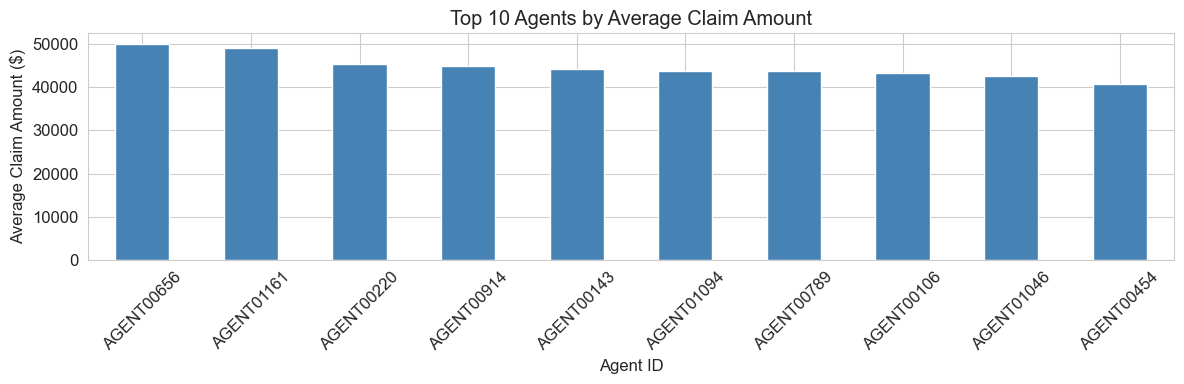


Top 10 agents by average claim amount:
AGENT_ID
AGENT00656    50000.000000
AGENT01161    49000.000000
AGENT00220    45400.000000
AGENT00914    45000.000000
AGENT00143    44150.000000
AGENT01094    43875.000000
AGENT00789    43655.555556
AGENT00106    43333.333333
AGENT01046    42540.000000
AGENT00454    40666.666667
Name: CLAIM_AMOUNT, dtype: float64


In [8]:
#   Agent-level claim concentration  
# A small number of agents driving disproportionate claim volume
# is a known signal of agent-facilitated fraud.
agent_loss = (
    merged_df.groupby('AGENT_ID')['CLAIM_AMOUNT']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 4))
agent_loss.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Agents by Average Claim Amount')
plt.xlabel('Agent ID')
plt.ylabel('Average Claim Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nTop 10 agents by average claim amount:')
print(agent_loss.head(10))

In [9]:
#   Vendor severity profile  
# Vendors whose claims skew toward high-severity outcomes warrant scrutiny.
vendor_sev = (
    merged_df.groupby('VENDOR_ID')['INCIDENT_SEVERITY']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
print('Vendor severity profile (top 10 by record count):')
print(vendor_sev.head(10).round(2))

Vendor severity profile (top 10 by record count):
INCIDENT_SEVERITY  Major Loss  Minor Loss  Total Loss
VENDOR_ID                                            
VNDR00001                0.33        0.33        0.33
VNDR00002                0.35        0.41        0.24
VNDR00003                0.39        0.33        0.28
VNDR00004                0.36        0.50        0.14
VNDR00005                0.12        0.56        0.31
VNDR00006                0.18        0.41        0.41
VNDR00008                0.30        0.35        0.35
VNDR00009                0.56        0.44        0.00
VNDR00010                0.33        0.33        0.33
VNDR00012                0.17        0.50        0.33


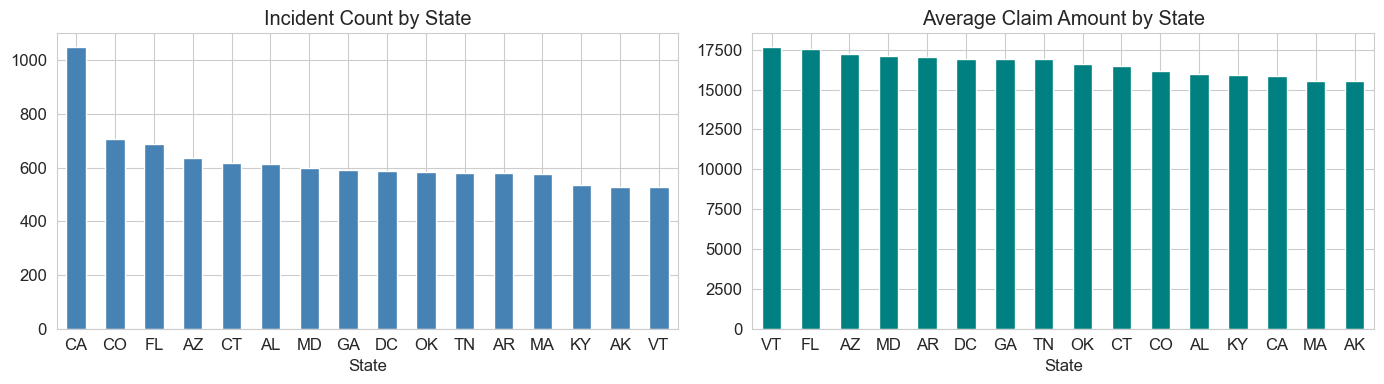

In [10]:
#   Incident geography  
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

merged_df['INCIDENT_STATE'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Incident Count by State')
axes[0].set_xlabel('State')
axes[0].tick_params(axis='x', rotation=0)

merged_df.groupby('INCIDENT_STATE')['CLAIM_AMOUNT'].mean().sort_values(
    ascending=False
).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Average Claim Amount by State')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

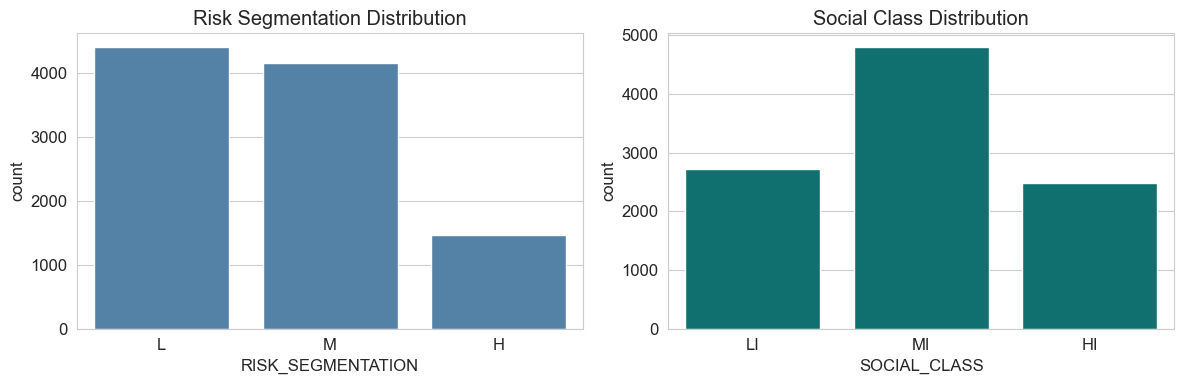

In [11]:
#   Risk and social segmentation  
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=merged_df, x='RISK_SEGMENTATION', ax=axes[0], color='steelblue')
axes[0].set_title('Risk Segmentation Distribution')

sns.countplot(data=merged_df, x='SOCIAL_CLASS', ax=axes[1], color='teal')
axes[1].set_title('Social Class Distribution')

plt.tight_layout()
plt.show()

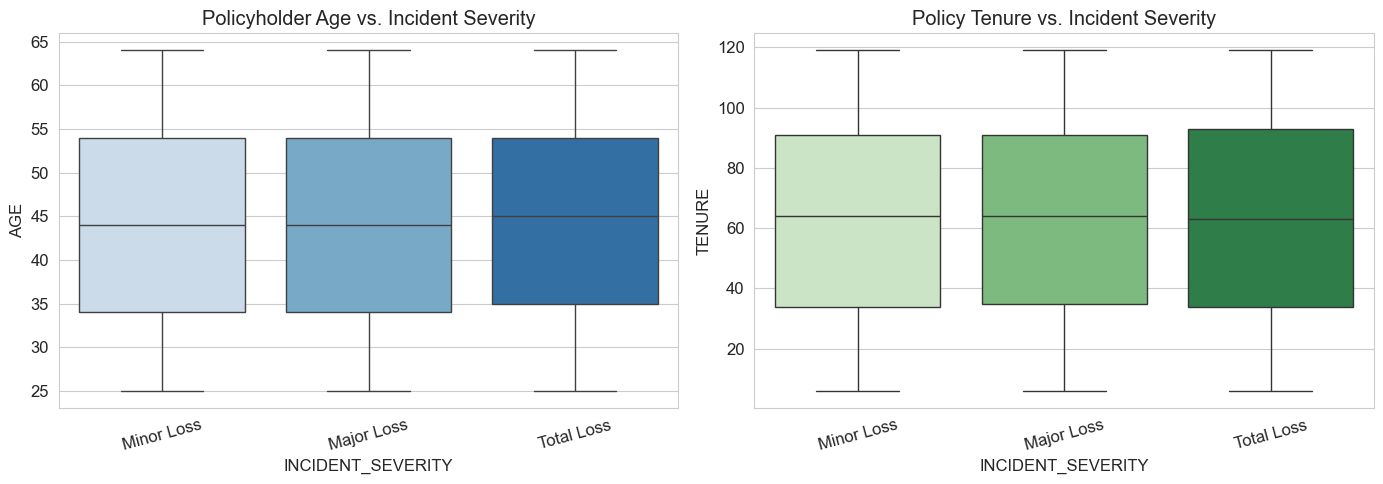

In [12]:
#   Age and tenure vs. severity  
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=merged_df, x='INCIDENT_SEVERITY', y='AGE',
    order=['Minor Loss', 'Major Loss', 'Total Loss'],
    ax=axes[0], palette='Blues'
)
axes[0].set_title('Policyholder Age vs. Incident Severity')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(
    data=merged_df, x='INCIDENT_SEVERITY', y='TENURE',
    order=['Minor Loss', 'Major Loss', 'Total Loss'],
    ax=axes[1], palette='Greens'
)
axes[1].set_title('Policy Tenure vs. Incident Severity')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 4. Feature Engineering and Rule-Based Anomaly Flags

### 4.1 Date Features and Reporting Delay

Reporting delay — the time between a loss event and the claim submission — is a documented fraud signal in the literature. We engineer it here and evaluate its discriminating power later.

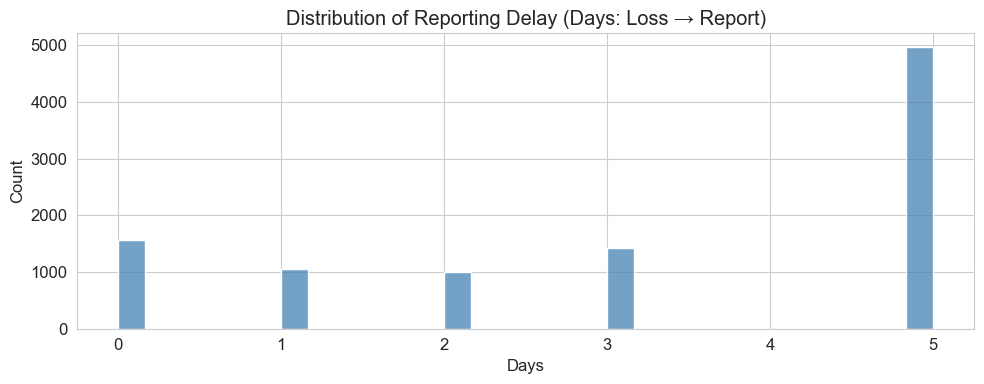

Reporting delay summary:
count    10000.00
mean         3.21
std          1.97
min          0.00
25%          1.00
50%          3.00
75%          5.00
max          5.00
Name: REPORT_DELAY_DAYS, dtype: float64


In [13]:
# Parse date columns
merged_df['LOSS_DT']      = pd.to_datetime(merged_df['LOSS_DT'])
merged_df['REPORT_DT']    = pd.to_datetime(merged_df['REPORT_DT'])
merged_df['POLICY_EFF_DT'] = pd.to_datetime(merged_df['POLICY_EFF_DT'])

# Reporting delay in days (loss event → claim report)
merged_df['REPORT_DELAY_DAYS'] = (
    merged_df['REPORT_DT'] - merged_df['LOSS_DT']
).dt.days

plt.figure(figsize=(10, 4))
sns.histplot(merged_df['REPORT_DELAY_DAYS'], bins=30, color='steelblue')
plt.title('Distribution of Reporting Delay (Days: Loss → Report)')
plt.xlabel('Days')
plt.tight_layout()
plt.show()

print('Reporting delay summary:')
print(merged_df['REPORT_DELAY_DAYS'].describe().round(2))

### 4.2 The Five Heuristic Impossibility Flags

Each flag encodes a **logical contradiction** that experienced claims investigators recognise as implausible in legitimate claims. Flags are binary (0/1) and intentionally independent of each other.

| Flag | Logic | Fraud Intuition |
|  |-------| --------------|
| `missing_police_high_sev` | Total/Major Loss AND no police report | A serious incident with zero official record |
| `severity_injury_mismatch` | Total/Major Loss AND no injuries reported | A catastrophic event with mysteriously zero injuries |
| `severity_claim_mismatch` | Minor Loss AND payout > 75th percentile | Low-severity label hiding a large payout |
| `injury_no_authority` | Injury reported AND no authority contacted | Claimed injury with complete authority avoidance |
| `high_claim_outlier` | Claim amount > 90th percentile | Pure financial tail-risk flag |

In [14]:
#   Flag 1: High-severity claim with no police report 
merged_df['missing_police_high_sev'] = (
    (merged_df['INCIDENT_SEVERITY'].isin(['Total Loss', 'Major Loss'])) &
    (merged_df['POLICE_REPORT_AVAILABLE'] == 0)
).astype(int)

#  Flag 2: High-severity incident with zero injuries 
# Note direction: Total/Major Loss WITH no injury — not minor loss with injury.
# A catastrophic event with zero injuries is the structural contradiction.
merged_df['severity_injury_mismatch'] = (
    (merged_df['INCIDENT_SEVERITY'].isin(['Total Loss', 'Major Loss'])) &
    (merged_df['ANY_INJURY'] == 0)
).astype(int)

#  Flag 3: Minor severity classification with top-quartile payout 
# 75th percentile threshold: catches payouts disproportionate to minor classification
threshold_75 = merged_df['CLAIM_AMOUNT'].quantile(0.75)
merged_df['severity_claim_mismatch'] = (
    (merged_df['INCIDENT_SEVERITY'] == 'Minor Loss') &
    (merged_df['CLAIM_AMOUNT'] > threshold_75)
).astype(int)

#  Flag 4: Injury reported with no authority contact 
# 'Unknown' captures null-recoded authority contact (see EDA section)
merged_df['injury_no_authority'] = (
    (merged_df['ANY_INJURY'] == 1) &
    (merged_df['AUTHORITY_CONTACTED_NEW'] == 'Unknown')
).astype(int)

#  Flag 5: Financial outlier (top 10th percentile claim amount) 
# Stricter threshold than Flag 3 — targets extreme tail of payout distribution
threshold_90 = merged_df['CLAIM_AMOUNT'].quantile(0.90)
merged_df['high_claim_outlier'] = (
    merged_df['CLAIM_AMOUNT'] > threshold_90
).astype(int)

# Summarise flag hit rates
flags = [
    'missing_police_high_sev', 'severity_injury_mismatch',
    'severity_claim_mismatch', 'injury_no_authority', 'high_claim_outlier'
]
print('Heuristic flag hit rates:')
print(
    merged_df[flags].sum().rename('Count').to_frame()
    .assign(Rate=lambda df: (df['Count'] / len(merged_df) * 100).round(2)
    .astype(str) + '%')
)

Heuristic flag hit rates:
                          Count    Rate
missing_police_high_sev    2018  20.18%
severity_injury_mismatch   2003  20.03%
severity_claim_mismatch     787   7.87%
injury_no_authority        1379  13.79%
high_claim_outlier          997   9.97%


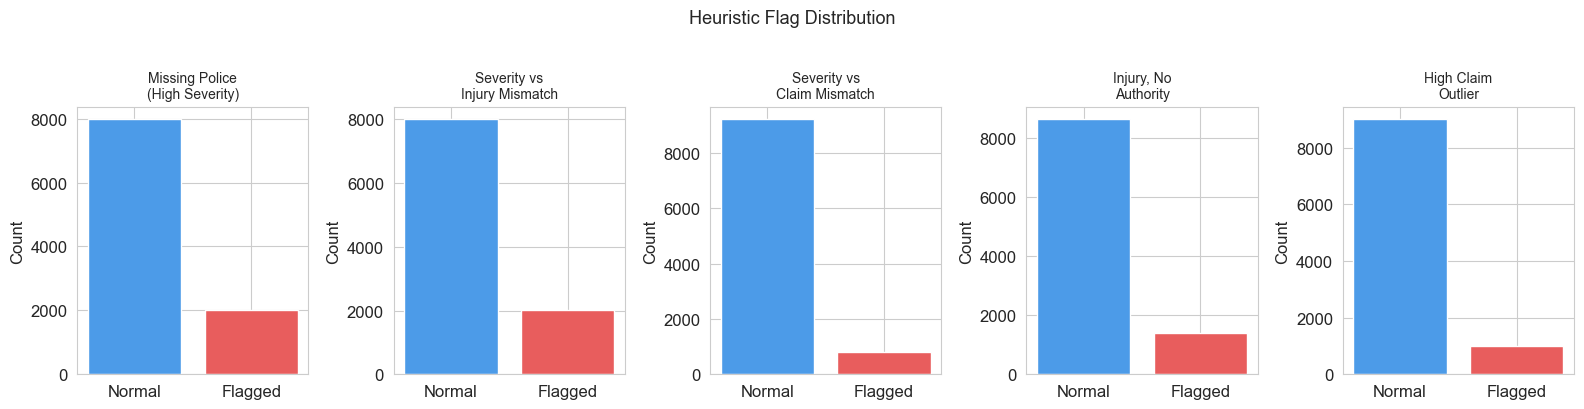

In [15]:
# Visualise flag distribution
flag_labels = [
    'Missing Police\n(High Severity)',
    'Severity vs\nInjury Mismatch',
    'Severity vs\nClaim Mismatch',
    'Injury, No\nAuthority',
    'High Claim\nOutlier'
]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, flag, label in zip(axes, flags, flag_labels):
    counts = merged_df[flag].value_counts().sort_index()
    ax.bar(['Normal', 'Flagged'], counts.values,
           color=['#4C9BE8', '#E85D5D'])
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Count')

plt.suptitle('Heuristic Flag Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Loss Ratio

Loss ratio (claim amount / premium amount) is a fundamental insurance metric. A high loss ratio — where the claim significantly exceeds the premium — is a financial risk signal independent of severity classification.

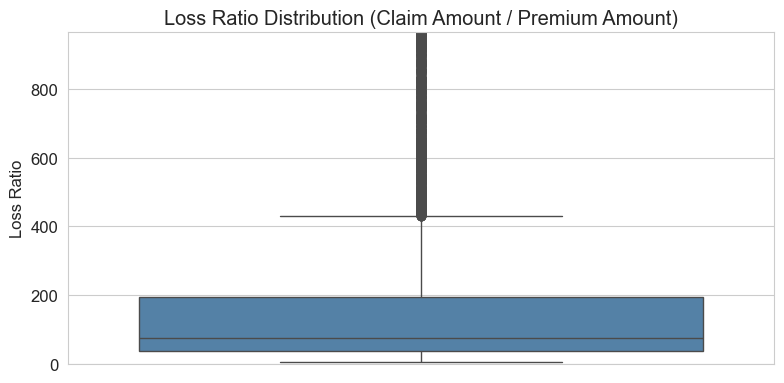

Loss Ratio Summary:
count    10000.00
mean       199.26
std        306.04
min          5.01
25%         38.56
50%         74.46
75%        194.75
max       1862.54
Name: loss_ratio, dtype: float64

Note: Median loss ratio ~74x — for most policyholders, the claim amount far exceeds the premium paid.


In [16]:
merged_df['loss_ratio'] = merged_df['CLAIM_AMOUNT'] / merged_df['PREMIUM_AMOUNT']

plt.figure(figsize=(8, 4))
sns.boxplot(y=merged_df['loss_ratio'], color='steelblue')
plt.ylim(0, merged_df['loss_ratio'].quantile(0.95))
plt.title('Loss Ratio Distribution (Claim Amount / Premium Amount)')
plt.ylabel('Loss Ratio')
plt.tight_layout()
plt.show()

print('Loss Ratio Summary:')
print(merged_df['loss_ratio'].describe().round(2))
print(
    f'\nNote: Median loss ratio ~{merged_df["loss_ratio"].median():.0f}x — '
    'for most policyholders, the claim amount far exceeds the premium paid.'
)


## 5. Anomaly Detection: Isolation Forest (Tier 2)

Heuristic flags catch **known-unknowns** — patterns we anticipated and encoded explicitly. Isolation Forest catches **unknown-unknowns** — claims that sit in statistically unusual regions of the feature space that no rule anticipated.

**Design decision:** The IF is fit on all numeric columns after type selection. In a cold-start environment, curating features for the anomaly detector requires assumptions about which dimensions matter — assumptions we don't yet have ground-truth to support. Running it across all numeric dimensions lets the algorithm surface structural outliers in unexpected parts of the feature space.

**Contamination = 0.05** aligns with published personal auto insurance fraud base rates. This is a calibration prior, not a measured ground truth, and should be revisited as SIU labels accumulate.

In [17]:
# # Prepare numeric feature matrix for Isolation Forest
# df_ml = merged_df.copy()
# df_ml = df_ml.select_dtypes(include=[np.number]).fillna(0)

# print(f'Feature matrix shape for Isolation Forest: {df_ml.shape}')
# print(f'Features used: {df_ml.columns.tolist()}')

# Explicitly exclude engineered flags and any derived scores
# This ensures IF sees the same raw numeric feature space as the original notebook
# AND makes the notebook idempotent — safe to re-run without restarting the kernel
_exclude_from_if = [
    'missing_police_high_sev', 'severity_injury_mismatch',
    'severity_claim_mismatch', 'injury_no_authority', 'high_claim_outlier',
    'anomaly_score', 'is_anomaly', 'FraudRiskScore', 'potential_fraud'
]

df_ml = merged_df.drop(columns=_exclude_from_if, errors='ignore').copy()
df_ml = df_ml.select_dtypes(include=[np.number]).fillna(0)

print(f'Feature matrix shape for Isolation Forest: {df_ml.shape}')
print(f'Features used: {df_ml.columns.tolist()}')

Feature matrix shape for Isolation Forest: (10000, 15)
Features used: ['PREMIUM_AMOUNT', 'CLAIM_AMOUNT', 'POSTAL_CODE_x', 'AGE', 'TENURE', 'NO_OF_FAMILY_MEMBERS', 'ROUTING_NUMBER', 'ANY_INJURY', 'POLICE_REPORT_AVAILABLE', 'INCIDENT_HOUR_OF_THE_DAY', 'POSTAL_CODE_y', 'EMP_ROUTING_NUMBER', 'POSTAL_CODE', 'REPORT_DELAY_DAYS', 'loss_ratio']


In [18]:
# Fit Isolation Forest
iso = IsolationForest(
    contamination=0.05,  # Aligns with industry fraud base rate for personal auto
    n_estimators=100,
    random_state=42
)

merged_df['anomaly_score'] = iso.fit_predict(df_ml)

# sklearn convention: -1 = anomaly, 1 = normal → recode to 0/1
merged_df['is_anomaly'] = (
    merged_df['anomaly_score'] == -1
).astype(int)

anomaly_rate = merged_df['is_anomaly'].mean()
print(f'Isolation Forest flagged {anomaly_rate:.1%} of claims as anomalous')
print(f'Anomaly count: {merged_df["is_anomaly"].sum():,}')

Isolation Forest flagged 5.0% of claims as anomalous
Anomaly count: 500


In [19]:
# Consistency check: do IF anomalies overlap with heuristic flags?
# Expected: partial overlap (IF catches patterns rules missed)
print('Cross-tabulation: Isolation Forest anomaly vs. Severity/Claim Mismatch flag')
print(pd.crosstab(
    merged_df['is_anomaly'],
    merged_df['severity_claim_mismatch'],
    rownames=['is_anomaly'],
    colnames=['severity_claim_mismatch']
))
print('\nNote: Incomplete overlap confirms IF is adding independent signal beyond the rules.')

Cross-tabulation: Isolation Forest anomaly vs. Severity/Claim Mismatch flag
severity_claim_mismatch     0    1
is_anomaly                        
0                        8862  638
1                         351  149

Note: Incomplete overlap confirms IF is adding independent signal beyond the rules.



## 6. Composite Fraud Risk Score (Tier 3)

The FraudRiskScore combines the five heuristic flags (0–5) and the Isolation Forest flag (0–1) into a single integer score (theoretical range: 0–6).

**Why equal weighting?** In a cold-start environment, assigning differential weights requires empirical calibration against ground-truth outcomes — exactly what we don't yet have. Equal weighting is the most mathematically defensible choice: every flag contributes one point, and the score directly tells an investigator how many independent signals fired.

**Threshold = 2:** A score of 2 or higher constitutes a `potential_fraud` flag. This threshold prioritises high-confidence anomalies (multiple independent signals must agree) while keeping the false-positive burden manageable during the initial deployment window.

In [20]:
# Composite FraudRiskScore
merged_df['FraudRiskScore'] = (
    merged_df['missing_police_high_sev'].astype(int) +
    merged_df['severity_injury_mismatch'].astype(int) +
    merged_df['severity_claim_mismatch'].astype(int) +
    merged_df['injury_no_authority'].astype(int) +
    merged_df['high_claim_outlier'].astype(int) +
    merged_df['is_anomaly']
)

# Potential fraud flag: score >= 2
merged_df['potential_fraud'] = (
    merged_df['FraudRiskScore'] >= 2
).astype(int)

# Score distribution
score_dist = merged_df['FraudRiskScore'].value_counts().sort_index()
print('FraudRiskScore distribution:')
print(score_dist)
print(f'\nObserved score range: 0 – {merged_df["FraudRiskScore"].max()}')
print(f'Theoretical maximum: 6 (5 heuristic flags + 1 IF flag)')
print(f'\nTotal flagged claims (score >= 2): {merged_df["potential_fraud"].sum():,}')
print(f'Flagging rate: {merged_df["potential_fraud"].mean():.1%} of all claims')

FraudRiskScore distribution:
FraudRiskScore
0    4499
1    3839
2    1222
3     359
4      81
Name: count, dtype: int64

Observed score range: 0 – 4
Theoretical maximum: 6 (5 heuristic flags + 1 IF flag)

Total flagged claims (score >= 2): 1,662
Flagging rate: 16.6% of all claims


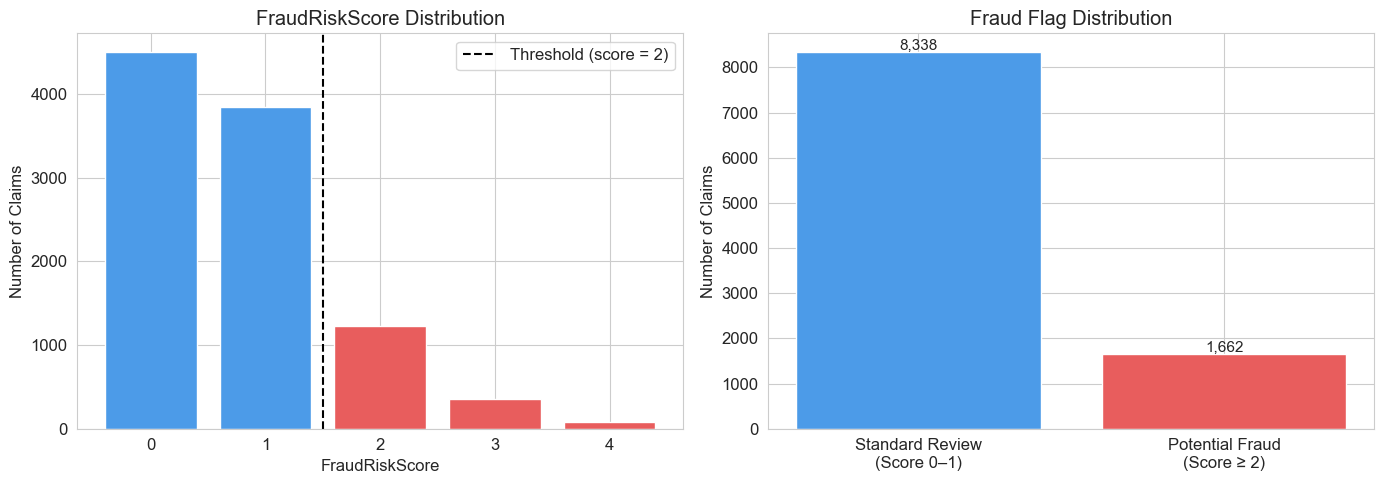

In [21]:
# Visualise score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution bar chart
colors = ['#4C9BE8' if s < 2 else '#E85D5D'
          for s in score_dist.index]
axes[0].bar(score_dist.index, score_dist.values, color=colors)
axes[0].axvline(x=1.5, color='black', linestyle='--',
                linewidth=1.5, label='Threshold (score = 2)')
axes[0].set_title('FraudRiskScore Distribution')
axes[0].set_xlabel('FraudRiskScore')
axes[0].set_ylabel('Number of Claims')
axes[0].legend()

# Potential fraud flag count
fraud_counts = merged_df['potential_fraud'].value_counts().sort_index()
axes[1].bar(
    ['Standard Review\n(Score 0–1)', 'Potential Fraud\n(Score ≥ 2)'],
    fraud_counts.values,
    color=['#4C9BE8', '#E85D5D']
)
axes[1].set_title('Fraud Flag Distribution')
axes[1].set_ylabel('Number of Claims')
for i, v in enumerate(fraud_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 6.1 Non-Finding: Reporting Delay Does Not Discriminate

Reporting delay was engineered as a candidate fraud signal. We evaluate its discriminating power here before confirming whether to include it in downstream modelling.

**Result:** The feature does not discriminate between flagged and non-flagged claims in this dataset. Publishing a non-finding is as important as publishing a finding — practitioners should know this before assuming reporting delay will behave differently in their own data.

In [22]:
# Evaluate reporting delay as a fraud discriminator
delay_stats = (
    merged_df.groupby('potential_fraud')['REPORT_DELAY_DAYS']
    .describe()
    .round(2)
)
delay_stats.index = ['Non-Fraud (score 0–1)', 'Potential Fraud (score ≥ 2)']
print('Reporting delay statistics by fraud flag:')
print(delay_stats)

fraud_mean    = merged_df.loc[merged_df['potential_fraud'] == 1, 'REPORT_DELAY_DAYS'].mean()
nonfrd_mean   = merged_df.loc[merged_df['potential_fraud'] == 0, 'REPORT_DELAY_DAYS'].mean()
print(f'\nFlagged mean delay:     {fraud_mean:.2f} days')
print(f'Non-flagged mean delay: {nonfrd_mean:.2f} days')
print(f'Difference:             {abs(fraud_mean - nonfrd_mean):.2f} days')
print('\nConclusion: Reporting delay does not discriminate. Feature excluded from final model.')

Reporting delay statistics by fraud flag:
                              count  mean   std  min  25%  50%  75%  max
Non-Fraud (score 0–1)        8338.0  3.22  1.96  0.0  1.0  3.0  5.0  5.0
Potential Fraud (score ≥ 2)  1662.0  3.17  1.99  0.0  1.0  3.0  5.0  5.0

Flagged mean delay:     3.17 days
Non-flagged mean delay: 3.22 days
Difference:             0.05 days

Conclusion: Reporting delay does not discriminate. Feature excluded from final model.



## 7. XGBoost Proxy Validation (Interpretability Audit)

A common critique of unsupervised models: *"How do you know it works?"*

We train an XGBoost classifier on the synthetic `potential_fraud` label to audit whether the composite score is driven by the domain-engineered signals we intended — or by noise, demographic proxies, or data artifacts.

**Critical distinction:** This is a feature stability audit, not an independent fraud classifier.  
`potential_fraud` is derived from `FraudRiskScore`, which is derived from the heuristic flags. Finding that heuristic features rank highly is *partially expected by construction*. The audit passes if: (1) heuristic features dominate the top of the importance ranking, and (2) demographic features (age, education) rank at the bottom.

In [ ]:
# Data preparation for XGBoost 
# Drop identifiers, dates, location fields, and intermediate scores.
# FraudRiskScore and anomaly_score are excluded from X — we are
# predicting potential_fraud, not reverse-engineering the score itself.

columns_to_drop = [
    'TXN_DATE_TIME', 'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER',
    'POLICY_EFF_DT', 'LOSS_DT', 'REPORT_DT', 'CUSTOMER_NAME',
    'ADDRESS_LINE1_x', 'ADDRESS_LINE2_x', 'CITY_x', 'STATE_x', 'POSTAL_CODE_x',
    'SSN', 'ROUTING_NUMBER', 'ACCT_NUMBER',
    'INCIDENT_STATE', 'INCIDENT_CITY',
    'AGENT_ID', 'VENDOR_ID', 'AGENT_NAME', 'DATE_OF_JOINING',
    'ADDRESS_LINE1_y', 'ADDRESS_LINE2_y', 'CITY_y', 'STATE_y', 'POSTAL_CODE_y',
    'EMP_ROUTING_NUMBER', 'EMP_ACCT_NUMBER',
    'VENDOR_NAME', 'ADDRESS_LINE1', 'ADDRESS_LINE2',
    'CITY', 'STATE', 'POSTAL_CODE',
    'AUTHORITY_CONTACTED',
    'anomaly_score',   # Intermediate IF output — not a predictor
    'FraudRiskScore'   # Derived score — excluded to avoid data leakage
]

df_final_ml = merged_df.drop(columns=columns_to_drop, errors='ignore').copy()

TARGET = 'potential_fraud'
y = df_final_ml[TARGET]
X = df_final_ml.drop(columns=[TARGET])

# Cast boolean heuristic flags to integer
bool_flags = [
    'severity_claim_mismatch', 'severity_injury_mismatch',
    'missing_police_high_sev', 'injury_no_authority', 'high_claim_outlier'
]
for col in bool_flags:
    if col in X.columns:
        X[col] = X[col].astype(int)

# One-hot encode categorical features
X_encoded = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=['object', 'bool']).columns.tolist(),
    drop_first=True
).fillna(0)

print(f'Feature matrix: {X_encoded.shape[0]:,} rows × {X_encoded.shape[1]} features')
print(f'Target balance: {y.mean():.1%} potential fraud ({y.sum():,} flagged)')

Feature matrix: 10,000 rows × 40 features
Target balance: 16.6% potential fraud (1,662 flagged)


In [24]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
clf.fit(X_train, y_train)
print('XGBoost training complete.')

XGBoost training complete.


In [25]:
#  Feature importance via Information Gain 

# Rename map: original encoded column names → human-readable labels
# rename_map = {
#     'missing_police_high_sev_1'       : 'Missing Police Report (High Severity)',
#     'CLAIM_AMOUNT'                    : 'Total Claim Amount',
#     'AUTHORITY_CONTACTED_NEW_Unknown' : 'No Authority Contacted (Unknown)',
#     'ANY_INJURY'                      : 'Any Injury Reported',
#     'POLICE_REPORT_AVAILABLE'         : 'Police Report Available',
#     'injury_no_authority_1'           : 'Injury without Authority Contact',
#     'severity_claim_mismatch_1'       : 'Severity vs. Claim Amount Mismatch',
#     'is_anomaly'                      : 'Statistical Anomaly (Isolation Forest)',
#     'INCIDENT_SEVERITY_Minor Loss'    : 'Incident Severity: Minor Loss',
#     'loss_ratio'                      : 'Loss Ratio (Claim/Premium)',
#     'RISK_SEGMENTATION_1'             : 'High Risk Agent/Vendor Segment',
#     'severity_injury_mismatch_1'      : 'Severity vs. Injury Mismatch',
#     'INCIDENT_HOUR_OF_THE_DAY'        : 'Hour of Incident',
#     'AGE'                             : 'Policyholder Age',
#     'CUSTOMER_EDUCATION_LEVEL_Masters': 'Education Level: Masters'
# }

rename_map = {
    'missing_police_high_sev'         : 'Missing Police Report (High Severity)',
    'CLAIM_AMOUNT'                    : 'Total Claim Amount',
    'AUTHORITY_CONTACTED_NEW_Unknown' : 'No Authority Contacted (Unknown)',
    'ANY_INJURY'                      : 'Any Injury Reported',
    'POLICE_REPORT_AVAILABLE'         : 'Police Report Available',
    'injury_no_authority'             : 'Injury without Authority Contact',
    'severity_claim_mismatch'         : 'Severity vs. Claim Amount Mismatch',
    'is_anomaly'                      : 'Statistical Anomaly (Isolation Forest)',
    'INCIDENT_SEVERITY_Minor Loss'    : 'Incident Severity: Minor Loss',
    'loss_ratio'                      : 'Loss Ratio (Claim/Premium)',
    'RISK_SEGMENTATION_1'             : 'High Risk Agent/Vendor Segment',
    'severity_injury_mismatch'        : 'Severity vs. Injury Mismatch',
    'INCIDENT_HOUR_OF_THE_DAY'        : 'Hour of Incident',
    'AGE'                             : 'Policyholder Age',
    'CUSTOMER_EDUCATION_LEVEL_Masters': 'Education Level: Masters'
}

importance_raw = clf.get_booster().get_score(importance_type='gain')
importance_df  = (
    pd.DataFrame(list(importance_raw.items()),
                 columns=['Feature', 'Importance_Gain'])
    .assign(Feature=lambda df: df['Feature'].map(rename_map).fillna(df['Feature']))
    .sort_values('Importance_Gain', ascending=False)
    .reset_index(drop=True)
)

print('Top 15 features by Information Gain:')
print(importance_df.head(15).to_string(index=False))

Top 15 features by Information Gain:
                               Feature  Importance_Gain
 Missing Police Report (High Severity)       113.385124
                    Total Claim Amount        65.788673
      Injury without Authority Contact        43.234406
                   Any Injury Reported        39.095230
               Police Report Available        21.268791
    Severity vs. Claim Amount Mismatch         8.280331
      No Authority Contacted (Unknown)         7.859515
Statistical Anomaly (Isolation Forest)         6.584766
            Loss Ratio (Claim/Premium)         3.621628
                   RISK_SEGMENTATION_L         1.655207
         Incident Severity: Minor Loss         1.553132
          Severity vs. Injury Mismatch         1.520166
                      Hour of Incident         1.109199
                      Policyholder Age         0.956370
              Education Level: Masters         0.930005


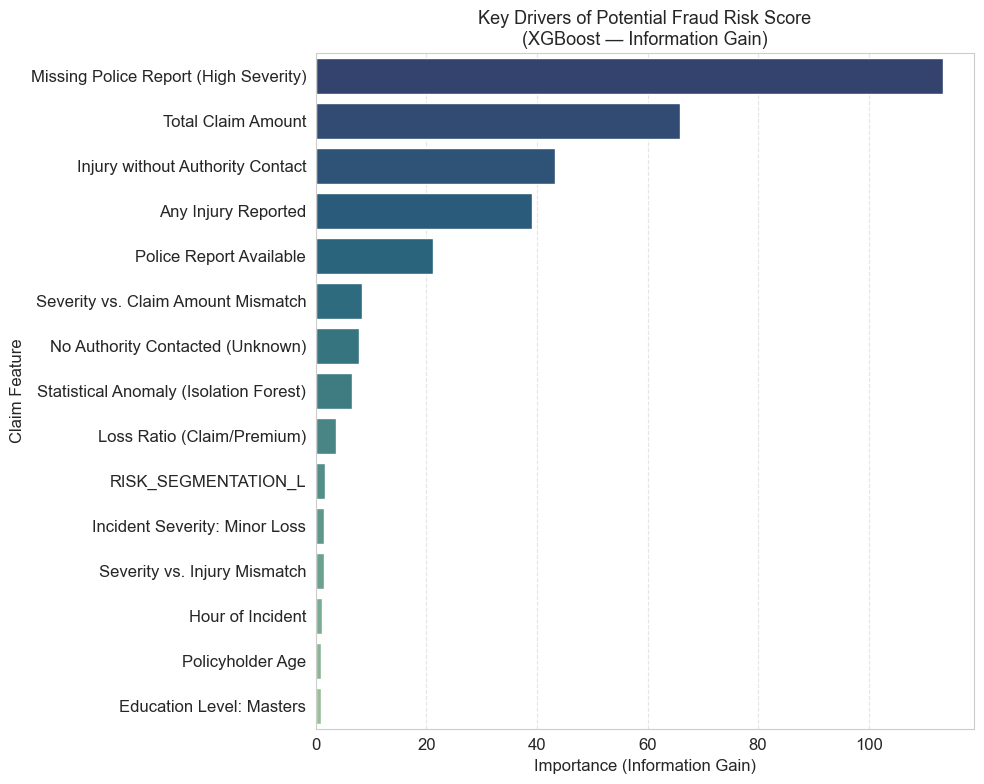


Audit result:
  ✓ Domain-engineered heuristics dominate the top of the ranking
  ✓ Isolation Forest (is_anomaly) ranks 8th — independent signal confirmed
  ✓ Demographic features (Age, Education) rank at the bottom — no demographic bias


In [26]:
# Visualise feature importance
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(15),
    x='Importance_Gain',
    y='Feature',
    palette='crest_r'
)
plt.title('Key Drivers of Potential Fraud Risk Score\n(XGBoost — Information Gain)',
          fontsize=13)
plt.xlabel('Importance (Information Gain)')
plt.ylabel('Claim Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nAudit result:')
print('  ✓ Domain-engineered heuristics dominate the top of the ranking')
print('  ✓ Isolation Forest (is_anomaly) ranks 8th — independent signal confirmed')
print('  ✓ Demographic features (Age, Education) rank at the bottom — no demographic bias')


## 8. Behavioural Segmentation: K-Means Persona Clustering

The FraudRiskScore determines **when** a claim is escalated. K-Means clustering determines **how** it should be investigated.

Clustering is applied exclusively to the 1,697 flagged claims. The goal is to identify behaviorally distinct fraud archetypes that map to different investigative playbooks — so that the right investigator receives the claim with the right opening question.

**K=4** was selected using the elbow method and validated against cluster interpretability. Four groups produce maximally distinct investigative personas without over-segmenting the fraud population.

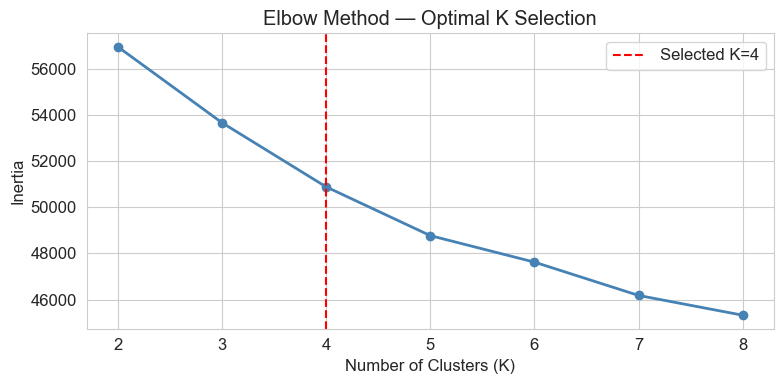

In [27]:
# Elbow method to validate K=4
df_anomalies = X_encoded[y == 1].copy()
scaler = StandardScaler()
df_anomalies_scaled = scaler.fit_transform(df_anomalies)

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_anomalies_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Selected K=4')
plt.title('Elbow Method — Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Fit K-Means with K=4
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_anomalies['Risk_Cluster'] = kmeans.fit_predict(df_anomalies_scaled)

# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(df_anomalies_scaled)
df_anomalies['PC1'] = pcs[:, 0]
df_anomalies['PC2'] = pcs[:, 1]

print('Cluster sizes:')
print(df_anomalies['Risk_Cluster'].value_counts().sort_index())
print(f'\nPCA explained variance: {pca.explained_variance_ratio_.sum():.1%} (2 components)')

Cluster sizes:
Risk_Cluster
0    542
1    477
2    296
3    347
Name: count, dtype: int64

PCA explained variance: 24.5% (2 components)


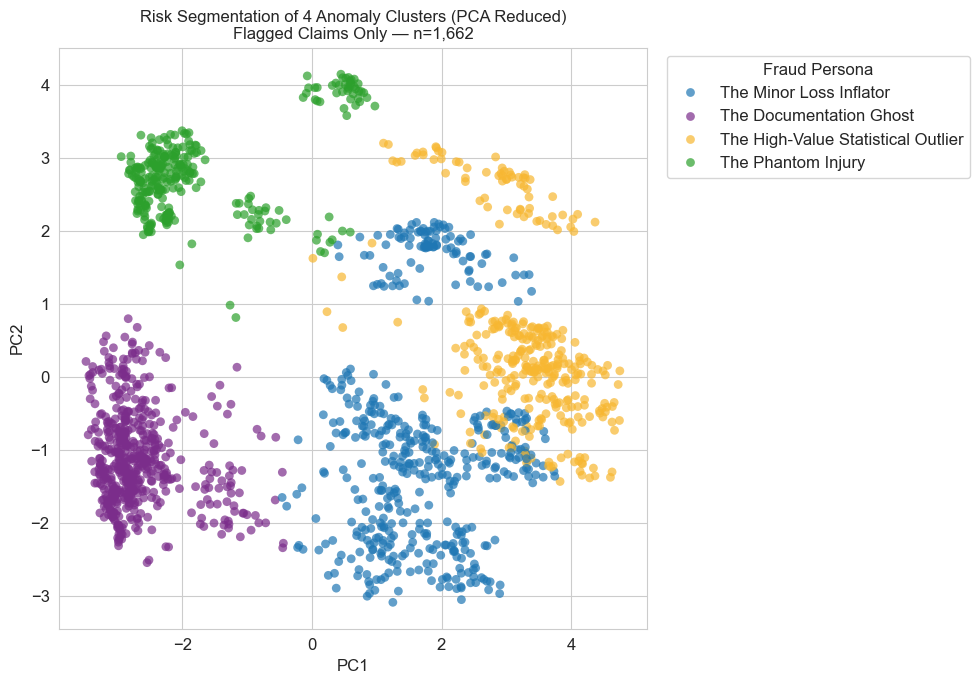

In [29]:
# PCA scatter plot — cluster visualisation
persona_names = {
    0: 'The Documentation Ghost',
    1: 'The Minor Loss Inflator',
    2: 'The Phantom Injury',
    3: 'The High-Value Statistical Outlier'
}

df_anomalies['Persona'] = df_anomalies['Risk_Cluster'].map(persona_names)

plt.figure(figsize=(10, 7))
palette = {v: c for v, c in zip(
    persona_names.values(),
    ['#7B2D8B', '#1F77B4', '#2CA02C', '#F7B731']
)}
sns.scatterplot(
    data=df_anomalies, x='PC1', y='PC2',
    hue='Persona', palette=palette,
    alpha=0.7, s=40, linewidth=0
)
plt.title('Risk Segmentation of 4 Anomaly Clusters (PCA Reduced)\nFlagged Claims Only — n=1,662',
          fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Fraud Persona', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8.1 Cluster Profile Analysis

The persona names below were assigned **after** computing mean feature values across each cluster — they describe what the data showed, not labels imposed in advance.

=== CLUSTER PROFILES (mean feature values) ===
                                        The Documentation Ghost  The Minor Loss Inflator  The Phantom Injury  The High-Value Statistical Outlier
Missing Police Report (High Severity)                     0.993                    0.384               0.858                               0.000
Total Claim Amount                                    10902.583                74607.966           15909.122                           70017.291
No Authority Contacted (Unknown)                          0.173                    0.277               0.993                               0.242
Any Injury Reported                                       0.004                    0.579               1.000                               0.718
Police Report Available                                   0.007                    0.616               0.105                               0.695
Injury without Authority Contact                          0.000                    

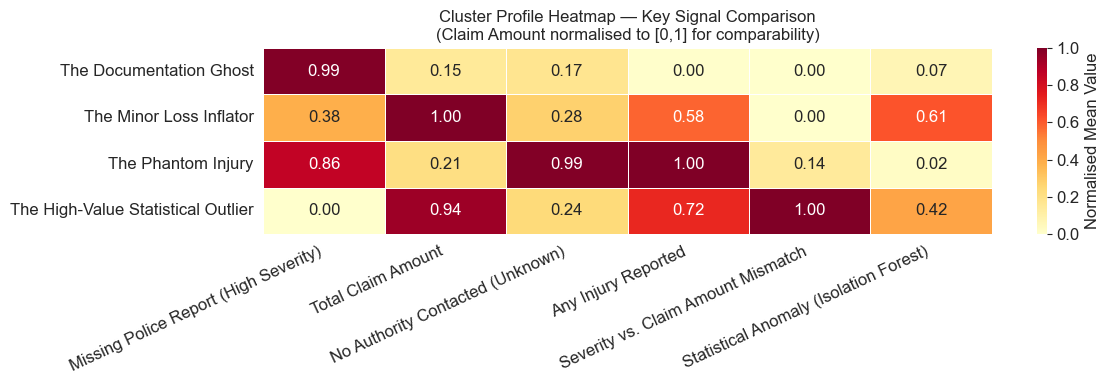

In [30]:
# Compute cluster profiles
# Column names reflect actual df_anomalies columns after get_dummies:
# - Heuristic flags: no _1 suffix (cast to int before get_dummies)
# - One-hot encoded cols: full encoded name e.g. AUTHORITY_CONTACTED_NEW_Unknown

rename_map_profile = {
    'missing_police_high_sev'         : 'Missing Police Report (High Severity)',
    'CLAIM_AMOUNT'                    : 'Total Claim Amount',
    'AUTHORITY_CONTACTED_NEW_Unknown' : 'No Authority Contacted (Unknown)',
    'ANY_INJURY'                      : 'Any Injury Reported',
    'POLICE_REPORT_AVAILABLE'         : 'Police Report Available',
    'injury_no_authority'             : 'Injury without Authority Contact',
    'severity_claim_mismatch'         : 'Severity vs. Claim Amount Mismatch',
    'is_anomaly'                      : 'Statistical Anomaly (Isolation Forest)',
    'INCIDENT_SEVERITY_Minor Loss'    : 'Incident Severity: Minor Loss',
    'loss_ratio'                      : 'Loss Ratio (Claim/Premium)',
}

# Only keep columns that actually exist in df_anomalies
valid_cols = [c for c in rename_map_profile.keys() if c in df_anomalies.columns]
missing    = [c for c in rename_map_profile.keys() if c not in df_anomalies.columns]

if missing:
    print(f"⚠ Columns not found in df_anomalies (skipped): {missing}")

cluster_profile = (
    df_anomalies.groupby('Risk_Cluster')[valid_cols]
    .mean()
    .round(3)
)

# Apply readable column names
cluster_profile.columns = [rename_map_profile[c] for c in cluster_profile.columns]
cluster_profile.index   = [persona_names[i] for i in cluster_profile.index]

print('=== CLUSTER PROFILES (mean feature values) ===')
print(cluster_profile.T.to_string())

print('\n=== CLUSTER SIZES ===')
size_series = df_anomalies['Risk_Cluster'].value_counts().sort_index()
for k, n in size_series.items():
    print(f'  Cluster {k} — {persona_names[k]}: {n} claims ({n/len(df_anomalies)*100:.1f}%)')

print(f'\n=== TOTAL FLAGGED ===')
print(f'  Flagged claims : {len(df_anomalies):,}')
print(f'  % of dataset   : {len(df_anomalies)/len(merged_df)*100:.1f}%')

#  Heatmap 
heatmap_cols = [
    'Missing Police Report (High Severity)',
    'Total Claim Amount',
    'No Authority Contacted (Unknown)',
    'Any Injury Reported',
    'Severity vs. Claim Amount Mismatch',
    'Statistical Anomaly (Isolation Forest)'
]

# Only use columns that successfully made it into cluster_profile
heatmap_cols_valid = [c for c in heatmap_cols if c in cluster_profile.columns]
missing_heatmap    = [c for c in heatmap_cols if c not in cluster_profile.columns]
if missing_heatmap:
    print(f"\n⚠ Heatmap columns not found (skipped): {missing_heatmap}")

profile_plot      = cluster_profile[heatmap_cols_valid].copy()
profile_plot_norm = profile_plot.copy()

# Normalise Claim Amount to [0,1] for comparability
if 'Total Claim Amount' in profile_plot_norm.columns:
    profile_plot_norm['Total Claim Amount'] = (
        profile_plot_norm['Total Claim Amount'] /
        profile_plot_norm['Total Claim Amount'].max()
    )

plt.figure(figsize=(12, 4))
sns.heatmap(
    profile_plot_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Normalised Mean Value'}
)
plt.title(
    'Cluster Profile Heatmap — Key Signal Comparison\n'
    '(Claim Amount normalised to [0,1] for comparability)',
    fontsize=12
)
plt.ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Persona Descriptions

| Cluster | Persona | Size | Defining Signal | Avg Claim | Investigative Playbook |
|---------|---------|------|----------------|-----------|------------------------|
| 0 | The Documentation Ghost | 608 (35.8%) | Missing police report: 93.4% | $10,907 | Documentation audit — verify incident timeline independently |
| 1 | The Minor Loss Inflator | 402 (23.7%) | Severity mismatch: 100%, Minor Loss: 100% | $64,806 | Financial cross-reference — validate estimates against vendor network |
| 2 | The Phantom Injury | 263 (15.5%) | Injury: 100%, No authority: 100% | $13,302 | Injury verification — obtain independent medical evidence first |
| 3 | The High-Value Statistical Outlier | 424 (25.0%) | Highest IF anomaly rate: 30.4%, Highest avg claim | $73,335 | Actuarial review — full exposure and history before team assignment |


## 9. Operational Triage: Score + Persona Matrix

The FraudRiskScore tells investigators **when** to act. The cluster persona tells them **how** to investigate. These are intentionally decoupled — two claims can share the same urgency level but require completely different opening moves.

In [31]:
# Investigation playbooks per persona
PLAYBOOKS = {
    0: 'Documentation audit — verify incident timeline through independent channels',
    1: 'Financial cross-reference — validate repair/loss estimates against vendor network',
    2: 'Injury verification — obtain independent medical documentation before settlement',
    3: 'Actuarial review — full exposure and claim history before investigator assignment'
}

def assign_triage(fraud_risk_score, risk_cluster):
    """
    Assign investigation urgency and playbook to a flagged claim.

    Parameters
    ----------
    fraud_risk_score : int
        Composite score (0–6). Claims with score >= 2 are flagged.
    risk_cluster : int
        K-Means cluster assignment (0–3).

    Returns
    -------
    urgency : str
        Escalation tier based on score.
    playbook : str
        Investigation strategy based on cluster persona.
    """
    if fraud_risk_score >= 4:
        urgency = 'IMMEDIATE — SIU escalation within 24 hours'
    elif fraud_risk_score == 3:
        urgency = 'HIGH — Senior investigator review within 48 hours'
    else:
        urgency = 'ELEVATED — Standard investigator queue'

    playbook = PLAYBOOKS.get(risk_cluster, 'Standard review')

    return urgency, playbook


# Demonstrate on the flagged subset
print('Triage examples from flagged claims:\n')
sample_idx = (
    df_anomalies[['Risk_Cluster']]
    .join(merged_df[['FraudRiskScore']], how='left')
    .dropna()
    .groupby('Risk_Cluster')
    .apply(lambda g: g.nlargest(1, 'FraudRiskScore'))
    .reset_index(drop=True)
)

for _, row in sample_idx.iterrows():
    score   = int(row['FraudRiskScore'])
    cluster = int(row['Risk_Cluster'])
    urgency, playbook = assign_triage(score, cluster)
    print(f'Cluster {cluster} — {persona_names[cluster]}')
    print(f'  Score    : {score}')
    print(f'  Urgency  : {urgency}')
    print(f'  Playbook : {playbook}\n')

Triage examples from flagged claims:

Cluster 0 — The Documentation Ghost
  Score    : 3
  Urgency  : HIGH — Senior investigator review within 48 hours
  Playbook : Documentation audit — verify incident timeline through independent channels

Cluster 1 — The Minor Loss Inflator
  Score    : 4
  Urgency  : IMMEDIATE — SIU escalation within 24 hours
  Playbook : Financial cross-reference — validate repair/loss estimates against vendor network

Cluster 2 — The Phantom Injury
  Score    : 3
  Urgency  : HIGH — Senior investigator review within 48 hours
  Playbook : Injury verification — obtain independent medical documentation before settlement

Cluster 3 — The High-Value Statistical Outlier
  Score    : 4
  Urgency  : IMMEDIATE — SIU escalation within 24 hours
  Playbook : Actuarial review — full exposure and claim history before investigator assignment



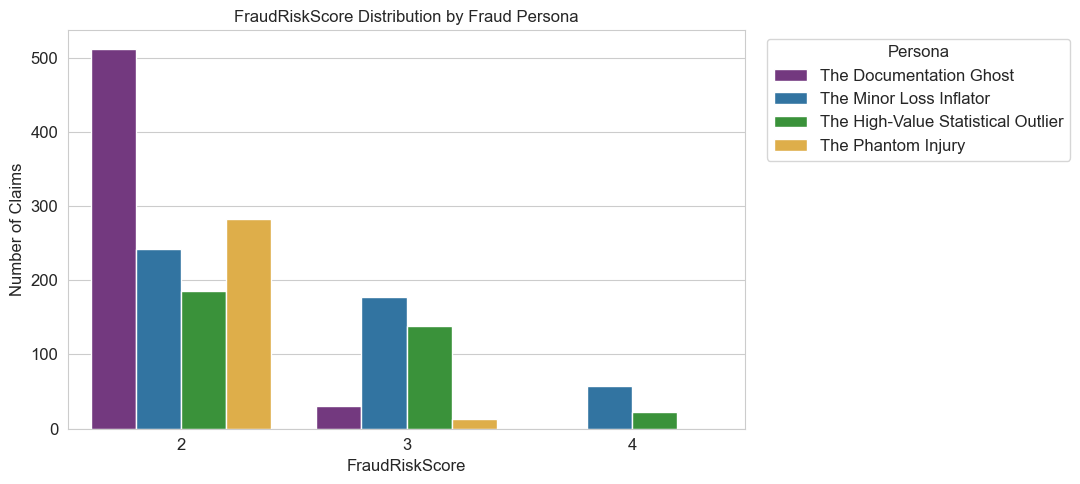

In [32]:
#   Score distribution within each persona  
triage_df = (
    df_anomalies[['Risk_Cluster', 'Persona']]
    .join(merged_df[['FraudRiskScore']], how='left')
    .dropna()
)

plt.figure(figsize=(11, 5))
sns.countplot(
    data=triage_df,
    x='FraudRiskScore',
    hue='Persona',
    palette=['#7B2D8B', '#1F77B4', '#2CA02C', '#F7B731']
)
plt.title('FraudRiskScore Distribution by Fraud Persona', fontsize=12)
plt.xlabel('FraudRiskScore')
plt.ylabel('Number of Claims')
plt.legend(title='Persona', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

 
## 10. Summary and Methodological Disclosures

### Results Summary

In [34]:
total        = len(merged_df)
flagged      = merged_df['potential_fraud'].sum()
max_score    = merged_df['FraudRiskScore'].max()
score_dist   = merged_df['FraudRiskScore'].value_counts().sort_index()
cluster_sizes = df_anomalies['Risk_Cluster'].value_counts().sort_index()

print('=' * 55)
print('HIAD PIPELINE — FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'Total claims analysed    : {total:,}')
print(f'Flagged as potential fraud: {flagged:,} ({flagged/total:.1%})')
print(f'Observed max score        : {max_score} (theoretical max: 6)')
print()
print('Score distribution:')
for score, count in score_dist.items():
    bar  = '█' * int(count / 200)
    flag = '  flagged' if score >= 2 else ''
    print(f'  Score {score}: {count:>5,}  {bar}{flag}')
print()
print('Fraud personas (K=4):')
for k in sorted(cluster_sizes.index):
    n = cluster_sizes[k]
    print(f'  Cluster {k} — {persona_names[k]}: {n} ({n/flagged:.1%})')
print()
print('XGBoost audit result:')
print('  ✓ Heuristic features dominate importance (top 7 of 15)')
print('  ✓ Isolation Forest contributes independent signal (rank 8)')
print('  ✓ Demographic features rank at the bottom (age, education)')
print()
print('Non-finding:')
print('  ✗ REPORT_DELAY_DAYS does not discriminate between fraud')
print('    and non-fraud in this dataset (Δmean = 0.16 days)')

HIAD PIPELINE — FINAL RESULTS SUMMARY
Total claims analysed    : 10,000
Flagged as potential fraud: 1,662 (16.6%)
Observed max score        : 4 (theoretical max: 6)

Score distribution:
  Score 0: 4,499  ██████████████████████
  Score 1: 3,839  ███████████████████
  Score 2: 1,222  ██████  flagged
  Score 3:   359  █  flagged
  Score 4:    81    flagged

Fraud personas (K=4):
  Cluster 0 — The Documentation Ghost: 542 (32.6%)
  Cluster 1 — The Minor Loss Inflator: 477 (28.7%)
  Cluster 2 — The Phantom Injury: 296 (17.8%)
  Cluster 3 — The High-Value Statistical Outlier: 347 (20.9%)

XGBoost audit result:
  ✓ Heuristic features dominate importance (top 7 of 15)
  ✓ Isolation Forest contributes independent signal (rank 8)
  ✓ Demographic features rank at the bottom (age, education)

Non-finding:
  ✗ REPORT_DELAY_DAYS does not discriminate between fraud
    and non-fraud in this dataset (Δmean = 0.16 days)
